# **Meta-Labeling for Signal Reliability in High-Frequency Futures Data**

## 1. Spark and Setup

In [ ]:
!pip uninstall -y pyspark
!pip install "pyspark==3.5.6"

Found existing installation: pyspark 4.0.2
Uninstalling pyspark-4.0.2:
  Successfully uninstalled pyspark-4.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.4/317.4 MB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.2 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.6-py2.py3-none-any.whl size=317895798 sha256=b77c9d29ae64ea1f0c26a9957630c71e4e864c86def0196197c64a341cf2d919
  Stored in directory: /root/.cache/pip/wheels/64/62/f3/ec15656ea4ada0523cae62a1827fe7beb55d3c8c87174aad4a
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, 

In [ ]:
# For AWS setup
# template: https://penn-cis545-files.s3.amazonaws.com/emr-course-2025.yml
!curl -s https://checkip.amazonaws.com

# dont forget /32 at the end

136.118.160.42


In [ ]:
# Set to stack address
# outputs -> c&p
%set_env EMR_HOST=ec2-34-207-156-132.compute-1.amazonaws.com

env: EMR_HOST=ec2-34-207-156-132.compute-1.amazonaws.com


In [ ]:
# Connect to EMR cluster
from pyspark.sql import SparkSession
import os

spark = SparkSession.builder.appName("CIS-5450").remote("sc://{host}:15002".format(host=os.getenv('EMR_HOST'))).getOrCreate()

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

from decimal import FloatOperation
from functools import reduce
from pyspark import StorageLevel

In [ ]:
to_pandas = lambda sdf : pd.DataFrame(sdf.collect(), columns=sdf.columns)

## 2. Data Loading

***Dataset (From Project Desc.)***

Financial Markets Data from Project Description

- 11/15/2025 to 11/30/2025 (17.5 GB)
- 12/01/2025 to 12/15/2025 (5.5 GB)
- 12/16/2025 to 12/31/2025 (6.2 GB)
- 01/01/2026 to 01/15/2026 (20.3 GB)

Filter for ticker = 'CL.c.0' (Crude Oil Futures)

Define schema and load raw ticks data from S3

In [ ]:
# Define schema for sdf loading

schema = StructType([
    # Timestamp of receiving and exchange
    # - string cast later
    StructField('ts_rec', StringType(), nullable=True),
    StructField('ts_event', StringType(), nullable=True),

    # Record type
    StructField('rtype', IntegerType(), nullable=True),

    # Publisher ID (not used)
    StructField('publisher_id', IntegerType(), nullable=True),

    # ID for instrument
    StructField('instrument_id', IntegerType(), nullable=True),

    # Actions
    # - M Modify, R Reset, T Trade, F Fill, C Cancel, A Added
    StructField('action', StringType(), nullable=True),

    # Bid/Ask
    StructField('side', StringType(), nullable=True),

    # Price of order
    StructField('price', DoubleType(), nullable=True),

    # Volume of order
    StructField('size', IntegerType(), nullable=True),

    # Data Source
    StructField('channel_id', IntegerType(), nullable=True),

    # Unique ID
    StructField('order_id', LongType(), nullable=True),

    # Flags for trade condition, special order
    StructField('flags', IntegerType(), nullable=True),

    # Latency
    StructField('ts_in_delta', LongType(), nullable=True),

    # Sequence # for messages
    StructField('sequence', LongType(), nullable=True),

    # Ticker
    StructField('symbol', StringType(), nullable=True)
])

In [ ]:
raw_ticks_sdf = spark.read.csv('s3://daolin-cis5450/raw_data/*.csv', header=True, schema=schema)

In [ ]:
# Sanity check
raw_ticks_sdf.createOrReplaceTempView("raw_ticks_sdf")
raw_ticks_sdf.show(5)

+--------------------+--------------------+-----+------------+-------------+------+----+-----+----+----------+-------------+-----+-----------+--------+------+
|              ts_rec|            ts_event|rtype|publisher_id|instrument_id|action|side|price|size|channel_id|     order_id|flags|ts_in_delta|sequence|symbol|
+--------------------+--------------------+-----+------------+-------------+------+----+-----+----+----------+-------------+-----+-----------+--------+------+
|2026-01-01T00:00:...|2025-12-28T13:01:...|  160|           1|       383438|     A|   B|56.86|   1|        26|8059518618704|   40|          0|   54516|CL.c.0|
|2026-01-01T00:00:...|2025-12-28T13:01:...|  160|           1|       383438|     A|   B|56.82|   1|        26|8059518535721|   40|          0|   54516|CL.c.0|
|2026-01-01T00:00:...|2025-12-28T13:01:...|  160|           1|       383438|     A|   B|56.78|   1|        26|8059518469314|   40|          0|   54516|CL.c.0|
|2026-01-01T00:00:...|2025-12-28T13:01:...|  1

## 3. Data Cleaning

**This project and dataset will be focused around Crude Oil Futures**

Cleanning steps

* Filter instrument: keep only CL.c.0 (Crude Oil Futures)
* Normalize timestamps: convert to Spark-compatible format
* Remove non-market events: drop reset (R) rows
* Sort events: order by time and sequence
* Validate data: keep rows with positive price and size
* Drop unused columns: reduce memory and improve performance

Afterwards, write parquet to S3 to save progress

In [ ]:
# Cleaning pipeline
TICKER = 'CL.c.0'

def clean_data(sdf):
  return(
    # Clean timestamp and cast to TimestampNTZType()
    # - remove extra Z
    # - trim nano -> micro (for Spark)
    sdf.withColumn('ts_event', to_timestamp_ntz(substring(regexp_replace(col('ts_event'),'Z',''),1,26)))
       .withColumn('ts_rec', to_timestamp_ntz(substring(regexp_replace(col('ts_rec'),'Z',''),1,26)))

    # Filter by ticker
       .filter(col('symbol') == TICKER)

    # Keep only market events (drop reset R)
       .filter(col('action') != 'R')

    # Sort
       .orderBy('ts_event','channel_id','sequence')

    # Remove bad prices and sizez
       .filter((col('price') > 0) & (col('size') > 0))

    # Drop cols not needed
       .drop('ts_rec','rtype','publisher_id','instrument_id','flags','ts_in_delta','symbol', 'order_id')
  )

In [ ]:
cleaned_ticks_sdf = clean_data(raw_ticks_sdf)

In [ ]:
# Sanity check
cleaned_ticks_sdf.createOrReplaceTempView("cleaned_ticks_sdf")
cleaned_ticks_sdf.show(5)

+--------------------+------+----+-----+----+----------+--------+
|            ts_event|action|side|price|size|channel_id|sequence|
+--------------------+------+----+-----+----+----------+--------+
|2025-11-16 13:00:...|     A|   B|57.62|   2|        26|   52099|
|2025-11-16 13:00:...|     A|   B| 56.9|   1|        26|   52099|
|2025-11-16 13:00:...|     A|   B| 57.6|   1|        26|   52099|
|2025-11-16 13:00:...|     A|   B| 58.0|  50|        26|   52099|
|2025-11-16 13:00:...|     A|   B|57.25|   1|        26|   52099|
+--------------------+------+----+-----+----+----------+--------+
only showing top 5 rows



In [ ]:
# Type check
cleaned_ticks_sdf.printSchema()

root
 |-- ts_event: timestamp_ntz (nullable = true)
 |-- action: string (nullable = true)
 |-- side: string (nullable = true)
 |-- price: double (nullable = true)
 |-- size: integer (nullable = true)
 |-- channel_id: integer (nullable = true)
 |-- sequence: long (nullable = true)



In [ ]:
# Save, write parquet to s3
cleaned_ticks_sdf.write.mode('overwrite').parquet('s3://daolin-cis5450/data/ticks.parquet')

## 4. Feature Engineering

**Step 1: VOLUME BAR AGGREGATION**

**Goal:** Convert high-frequency tick data into stable, information-driven observations.


We construct **volume bars** by aggregating trades until a fixed volume threshold is reached.

* Target: **~100 bars per day**
* Threshold estimate: **rolling median of past daily vol**
* Rolling window length: **5 days**

```
threshold_t = median(daily_volume_{t-5:t-1}) / 100
```

**WHY**:

* each bar contains similar trading activity
* reduces noise
* avoid lookahead-bias using median of past daily volumes
* robust to outliers (median > mean for volume spikes)


The resulting volumes bars will serve as the basis data points for feature engineering.

---

---

**Step 2: Feature Engineering**

*Financial markets are noisy, especially at high frequency, and price alone doesn’t explain short-term movements. These features help the model understand market context, so it can learn when a signal is actually worth trusting.*

--

**Price & Momentum Features**

**Examples:** `log_return`, `ret_10`, `vwap_diff_pct`

* These features capture directional movement and short-term trends.

--


**Volatility & Rolling Statistics**

**Examples:** `rolling_std_10`, `realized_vol_5`

* These describe the local volatility regime and normalize behavior across different market conditions.

--

**Volume & Activity Features**

**Examples:** `rolling_mean_volume_10`, `volume_per_trade`

* These capture trading activity, intensity, regime shifts.

--

**Microstructure & Order Flow Features**

**Examples:** `trade_imbalance`, `net_book_flow`, `cancel_to_add_ratio`

* These features describe supply and demand dynamics at a granular level.

--

**Interaction & Lag Features**

**Examples:** `imbalance_x_volume`, `flow_pressure_lag1`

* Interaction features capture nonlinear relationships, while lag features introduce short-term memory of past conditions.

---

#### Load Cleaned Ticks

In [ ]:
# Read parquet of cleaned tick data from s3
ticks_sdf = spark.read.parquet('s3://daolin-cis5450/data/ticks.parquet').orderBy('ts_event')
ticks_sdf.createOrReplaceTempView('ticks_sdf')

In [ ]:
ticks_sdf.show(5)

+--------------------+------+----+-----+----+----------+--------+
|            ts_event|action|side|price|size|channel_id|sequence|
+--------------------+------+----+-----+----+----------+--------+
|2025-11-16 13:00:...|     A|   B| 58.1|   1|        26|   52099|
|2025-11-16 13:00:...|     A|   B|57.15|   2|        26|   52099|
|2025-11-16 13:00:...|     A|   B| 58.0|  50|        26|   52099|
|2025-11-16 13:00:...|     A|   B| 57.6|   1|        26|   52099|
|2025-11-16 13:00:...|     A|   B|57.25|   1|        26|   52099|
+--------------------+------+----+-----+----+----------+--------+
only showing top 5 rows



In [ ]:
ticks_sdf.count()

np.int64(63514245)

####Finding Volume Bars

In [ ]:
# Event-based sampling : bars
# - (*) volume bars
# - dollar bars

# Parameters
# - num bars per day: 100
# - threshold estimation: rolling median (stable, activity-adjusted)
# - expanding, rolling window length: 5

NUM_BARS_PER_DAY = 100
ROLLING_WINDOW_LENGTH = 5

# Calculate daily vol threshold for volume bars
query = f'''
WITH daily_volume AS (
  SELECT DATE(ts_event) AS date,
         SUM(size) AS vol
  FROM ticks_sdf
  WHERE action = 'T'
  GROUP BY date
),

thresholds AS (
  SELECT date, vol,
         PERCENTILE_APPROX(vol, 0.5) OVER (
            ORDER BY date
            ROWS BETWEEN {ROLLING_WINDOW_LENGTH-1} PRECEDING AND 1 PRECEDING
         ) AS rolling_median
  FROM daily_volume
)

SELECT date, rolling_median,
       rolling_median / {NUM_BARS_PER_DAY} AS vol_threshold
FROM thresholds
WHERE rolling_median IS NOT NULL
ORDER BY date
'''

daily_threshold_sdf = spark.sql(query)
daily_threshold_sdf.createOrReplaceTempView('daily_threshold_sdf')

In [ ]:
daily_threshold_sdf.show(5)

+----------+--------------+-------------+
|      date|rolling_median|vol_threshold|
+----------+--------------+-------------+
|2025-11-17|          2258|        22.58|
|2025-11-18|          2258|        22.58|
|2025-11-19|         33936|       339.36|
|2025-11-20|         12758|       127.58|
|2025-11-21|         12758|       127.58|
+----------+--------------+-------------+
only showing top 5 rows



In [ ]:
# Find bars and assign bar id
# - get cumulative volume per date
# - cumulative vol / threshold = bar_id
query = f'''
WITH ticks_w_threshold AS (
  SELECT t.*, d.vol_threshold
  FROM ticks_sdf AS t
  JOIN daily_threshold_sdf d
    ON DATE(t.ts_event) = d.date
  ORDER BY t.ts_event, t.channel_id, t.sequence
),

ticks_w_cum_vol AS (
  SELECT
    *,
    SUM(CASE WHEN action = 'T' THEN size ELSE 0 END) OVER (
      PARTITION BY DATE(ts_event)
      ORDER BY ts_event, channel_id, sequence
      ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cum_vol
  FROM ticks_w_threshold
  ORDER BY ts_event, channel_id, sequence
)

SELECT
    *,
    FLOOR(cum_vol / vol_threshold) AS bar_id
FROM ticks_w_cum_vol
'''

ticks_w_bars_sdf = spark.sql(query)
ticks_w_bars_sdf.createOrReplaceTempView('ticks_w_bars_sdf')

In [ ]:
ticks_w_bars_sdf.filter(col('action')=='T').show(3)

+--------------------+------+----+-----+----+----------+--------+-------------+-------+------+
|            ts_event|action|side|price|size|channel_id|sequence|vol_threshold|cum_vol|bar_id|
+--------------------+------+----+-----+----+----------+--------+-------------+-------+------+
|2025-11-17 00:00:...|     T|   B|59.55|   1|        26| 1338721|        22.58|      1|     0|
|2025-11-17 00:00:...|     T|   A|59.54|   1|        26| 1340588|        22.58|      2|     0|
|2025-11-17 00:00:...|     T|   N|59.55|   1|        26| 1340783|        22.58|      3|     0|
+--------------------+------+----+-----+----+----------+--------+-------------+-------+------+
only showing top 3 rows



#### Aggregate Per Bar

In [ ]:
query = f"""
-- first trade price in each bar --
WITH opens AS (
  SELECT
    DATE(ts_event) AS date,
    bar_id,
    price AS open
  FROM (
    SELECT *,
      ROW_NUMBER() OVER (
        PARTITION BY DATE(ts_event), bar_id
        ORDER BY ts_event, channel_id, sequence
      ) AS row_num
    FROM ticks_w_bars_sdf
    WHERE action = 'T'
      AND bar_id IS NOT NULL
  ) x
  WHERE row_num = 1
),

-- last trade price in each bar --
closes AS (
  SELECT
    DATE(ts_event) AS date,
    bar_id,
    price AS close
  FROM (
    SELECT *,
      ROW_NUMBER() OVER (
        PARTITION BY DATE(ts_event), bar_id
        ORDER BY ts_event DESC, channel_id DESC, sequence DESC
      ) AS row_num
    FROM ticks_w_bars_sdf
    WHERE action = 'T'
      AND bar_id IS NOT NULL
  ) x
  WHERE row_num = 1
),

-- trade-only base aggregation --
trade_base AS (
  SELECT
    DATE(ts_event) AS date,
    bar_id,
    MIN(ts_event) AS ts_open,
    MAX(ts_event) AS ts_close,
    MAX(price) AS high,
    MIN(price) AS low,
    SUM(size) AS volume,
    COUNT(*) AS n_trade,
    SUM(price * size) AS pxsz_sum,
    SUM(CASE WHEN side = 'A' THEN size ELSE 0 END) AS buy_vol,
    SUM(CASE WHEN side = 'B' THEN size ELSE 0 END) AS sell_vol
  FROM ticks_w_bars_sdf
  WHERE action = 'T'
    AND bar_id IS NOT NULL
  GROUP BY DATE(ts_event), bar_id
),

trade_agg AS (
  SELECT
    date,
    bar_id,
    ts_open,
    ts_close,
    high,
    low,
    volume,
    n_trade,
    unix_timestamp(ts_close) - unix_timestamp(ts_open) AS duration,
    CAST(pxsz_sum AS DOUBLE) / NULLIF(volume, 0) AS vwap,
    buy_vol,
    sell_vol,
    CASE
      WHEN (buy_vol + sell_vol) = 0 THEN 0.0
      ELSE CAST(buy_vol - sell_vol AS DOUBLE) / (buy_vol + sell_vol)
    END AS trade_imbalance,
    CASE
      WHEN (buy_vol + sell_vol) = 0 THEN 0.0
      ELSE CAST(buy_vol AS DOUBLE) / (buy_vol + sell_vol)
    END AS buy_ratio
  FROM trade_base
),

-- all-event base aggregation --
market_base AS (
  SELECT
    DATE(ts_event) AS date,
    bar_id,

    COUNT(*) AS n_actions,
    SUM(CASE WHEN action = 'A' THEN 1 ELSE 0 END) AS n_add,
    SUM(CASE WHEN action = 'C' THEN 1 ELSE 0 END) AS n_cancel,
    SUM(CASE WHEN action = 'M' THEN 1 ELSE 0 END) AS n_modify,
    SUM(CASE WHEN action = 'F' THEN 1 ELSE 0 END) AS n_fill,

    SUM(CASE WHEN action = 'A' THEN size ELSE 0 END) AS vol_add,
    SUM(CASE WHEN action = 'C' THEN size ELSE 0 END) AS vol_cancel,
    SUM(CASE WHEN action = 'M' THEN size ELSE 0 END) AS vol_modify,
    SUM(CASE WHEN action = 'F' THEN size ELSE 0 END) AS vol_fill

  FROM ticks_w_bars_sdf
  WHERE bar_id IS NOT NULL
  GROUP BY DATE(ts_event), bar_id
),

market_agg AS (
  SELECT
    t.date,
    t.bar_id,
    mb.n_actions,
    mb.n_add,
    mb.n_cancel,
    mb.n_modify,
    mb.n_fill,
    mb.vol_add,
    mb.vol_cancel,
    mb.vol_modify,
    mb.vol_fill,

    mb.vol_add - mb.vol_cancel AS net_book_flow,

    CASE
      WHEN mb.vol_add = 0 THEN 0.0
      ELSE CAST(mb.vol_cancel AS DOUBLE) / mb.vol_add
    END AS cancel_to_add_ratio,

    CASE
      WHEN (mb.n_add + mb.n_cancel) = 0 THEN 0.0
      ELSE CAST(mb.n_add - mb.n_cancel AS DOUBLE) / (mb.n_add + mb.n_cancel)
    END AS event_imbalance,

    CASE
      WHEN mb.n_actions = 0 THEN 0.0
      ELSE CAST(mb.n_modify AS DOUBLE) / mb.n_actions
    END AS modify_rate,

    CASE
      WHEN mb.n_actions = 0 THEN 0.0
      ELSE CAST(mb.n_cancel AS DOUBLE) / mb.n_actions
    END AS cancel_rate,

    CASE
      WHEN mb.n_actions = 0 THEN 0.0
      ELSE CAST(mb.n_fill AS DOUBLE) / mb.n_actions
    END AS fill_rate,

    CASE
      WHEN mb.n_actions = 0 THEN 0.0
      ELSE CAST(mb.n_add AS DOUBLE) / mb.n_actions
    END AS add_rate,

    CASE
      WHEN (mb.vol_add + mb.vol_cancel) = 0 THEN 0.0
      ELSE CAST(mb.vol_cancel AS DOUBLE) / (mb.vol_add + mb.vol_cancel)
    END AS withdrawal_rate,

    CASE
      WHEN (mb.vol_add + mb.vol_cancel) = 0 THEN 0.0
      ELSE CAST(mb.vol_add AS DOUBLE) / (mb.vol_add + mb.vol_cancel)
    END AS growth_rate,

    CASE
      WHEN (mb.vol_add + mb.vol_cancel) = 0 THEN 0.0
      ELSE CAST(t.volume AS DOUBLE) / (mb.vol_add + mb.vol_cancel)
    END AS aggression_ratio,

    CASE
      WHEN t.duration = 0 THEN 0.0
      ELSE CAST(t.volume AS DOUBLE) / t.duration
    END AS liquidity_speed

  FROM market_base mb
  JOIN trade_agg t
    ON mb.date = t.date AND mb.bar_id = t.bar_id
)



--- Features ---
SELECT
  a.ts_open,
  a.ts_close,

  o.open,
  a.high,
  a.low,
  c.close,
  a.volume,

  a.n_trade,
  a.buy_vol,
  a.sell_vol,
  a.trade_imbalance,
  a.buy_ratio,
  a.duration,
  a.vwap,

  m.net_book_flow,
  m.cancel_to_add_ratio,
  m.event_imbalance,
  m.modify_rate,
  m.cancel_rate,
  m.fill_rate,
  m.add_rate,
  m.withdrawal_rate,
  m.growth_rate,
  m.aggression_ratio,
  m.liquidity_speed,

  a.date,
  a.bar_id

FROM trade_agg a
JOIN opens o
  ON a.date = o.date AND a.bar_id = o.bar_id
JOIN closes c
  ON a.date = c.date AND a.bar_id = c.bar_id
JOIN market_agg m
  ON a.date = m.date AND a.bar_id = m.bar_id
ORDER BY a.date, a.bar_id
"""

bars_sdf = spark.sql(query)
bars_sdf.createOrReplaceTempView('bars_sdf')

In [ ]:
bars_sdf.show(3)

+--------------------+--------------------+-----+-----+-----+-----+------+-------+-------+--------+-------------------+------------------+--------+------------------+-------------+-------------------+-------------------+-------------------+-------------------+--------------------+-------------------+------------------+-------------------+--------------------+-------------------+----------+------+
|             ts_open|            ts_close| open| high|  low|close|volume|n_trade|buy_vol|sell_vol|    trade_imbalance|         buy_ratio|duration|              vwap|net_book_flow|cancel_to_add_ratio|    event_imbalance|        modify_rate|        cancel_rate|           fill_rate|           add_rate|   withdrawal_rate|        growth_rate|    aggression_ratio|    liquidity_speed|      date|bar_id|
+--------------------+--------------------+-----+-----+-----+-----+------+-------+-------+--------+-------------------+------------------+--------+------------------+-------------+-------------------+

#### Calculating Other Features

In [ ]:
# Start by filtering bars_sdf to get necessary cols
keep_cols = [
    "date","bar_id","ts_close","open","high","low","close","volume","n_trade","duration",
    "vwap","trade_imbalance","buy_ratio","net_book_flow","cancel_to_add_ratio","modify_rate",

    "withdrawal_rate","growth_rate","aggression_ratio","liquidity_speed","event_imbalance"
]

bars_base = bars_sdf.select(*[c for c in keep_cols if c in bars_sdf.columns])

# Ensure numeric columns are cast properly in bars_base
numeric_cols = ["open","high","low","close","volume","n_trade","duration","vwap","trade_imbalance","buy_ratio","net_book_flow",
                "cancel_to_add_ratio","modify_rate","withdrawal_rate","growth_rate","aggression_ratio","liquidity_speed","event_imbalance"]
for c in numeric_cols:
    if c in bars_base.columns:
        bars_base = bars_base.withColumn(c, F.col(c).cast("double"))

# Specifying windows for calculating rolling and lag features
w_ord = Window.orderBy("date", "bar_id")
w_5 = w_ord.rowsBetween(-4, 0)
w_10 = w_ord.rowsBetween(-9, 0)
w_20 = w_ord.rowsBetween(-19, 0)

# --- Time/Session Features ---
feat = (
    bars_base
    .withColumn("hour_of_day", F.hour("ts_close"))
    .withColumn("minute_of_hour", F.minute("ts_close"))
    .withColumn(
        "session_open_flag",
        F.when((F.col("hour_of_day") == 9) & (F.col("minute_of_hour") < 60), 1).otherwise(0)
    )
    .withColumn(
        "session_close_flag",
        F.when((F.col("hour_of_day") >= 15), 1).otherwise(0)
    )
)

# --- Additional Features ---
feat = (
    feat
    # intra-bar range / volatility proxy
    .withColumn(
        "hl_spread",
        F.when(F.col("low").isNull() | (F.col("low") == 0) | F.col("high").isNull(), None)
         .otherwise((F.col("high") - F.col("low")) / F.col("low")))

    # open-to-close return
    .withColumn(
        "oc_return",
        F.when(F.col("open").isNull() | (F.col("open") == 0) | F.col("close").isNull(), None)
         .otherwise((F.col("close") - F.col("open")) / F.col("open")))

    # volume per trade
    .withColumn(
        "volume_per_trade",
        F.when(F.col("n_trade").isNull() | (F.col("n_trade") == 0) | F.col("volume").isNull(), None)
         .otherwise(F.col("volume") / F.col("n_trade")))

    # trade intensity
    .withColumn(
        "trade_intensity",
        F.when(F.col("duration").isNull() | (F.col("duration") == 0) | F.col("n_trade").isNull(), None)
         .otherwise(F.col("n_trade") / F.col("duration")))

    # flow pressure
    .withColumn(
        "flow_pressure",
        F.when(F.col("volume").isNull() | (F.col("volume") == 0) | F.col("net_book_flow").isNull(), None)
         .otherwise(F.col("net_book_flow") / F.col("volume")))
)

# --- VWAP-based Features ---
feat = (
    feat
    .withColumn(
        "abs_vwap_diff",
        F.abs(F.col("close") - F.col("vwap")))
    .withColumn(
        "vwap_diff_pct",
        F.when(
            F.col("vwap").isNull() | (F.col("vwap") == 0), None)
         .otherwise((F.col("close") - F.col("vwap")) / F.col("vwap"))
    )
)

# --- Lag Features ---
feat = (
    feat
    # close lag for ret_n calculation
    .withColumn("close_lag1", F.lag("close", 1).over(w_ord))
    .withColumn("close_lag5", F.lag("close", 5).over(w_ord))
    .withColumn("close_lag10", F.lag("close", 10).over(w_ord))

    # lag 1 features (lag 1 for now)
    .withColumn("trade_imbalance_lag1", F.lag("trade_imbalance", 1).over(w_ord))
    .withColumn("net_book_flow_lag1", F.lag("net_book_flow", 1).over(w_ord))
    .withColumn("cancel_to_add_ratio_lag1", F.lag("cancel_to_add_ratio", 1).over(w_ord))
    .withColumn("modify_rate_lag1", F.lag("modify_rate", 1).over(w_ord))
    .withColumn("volume_lag1", F.lag("volume", 1).over(w_ord))
    .withColumn("flow_pressure_lag1", F.lag("flow_pressure", 1).over(w_ord))
    .withColumn("trade_intensity_lag1", F.lag("trade_intensity", 1).over(w_ord))
    .withColumn("abs_vwap_diff_lag1", F.lag("abs_vwap_diff", 1).over(w_ord))
    .withColumn("duration_lag1", F.lag("duration", 1).over(w_ord))
    .withColumn("n_trade_lag1", F.lag("n_trade", 1).over(w_ord))
)

# --- Return & Momentum Features ---
feat = (
    feat
    .withColumn(
        "log_return",
        F.when((F.col("close").isNull()) | (F.col("close_lag1").isNull()) | (F.col("close") <= 0) | (F.col("close_lag1") <= 0), None)
         .otherwise(F.log(F.col("close") / F.col("close_lag1")))
    )
    # momentum
    .withColumn(
        "mom_5",
        F.when(F.col("close_lag5").isNull(), None)
         .otherwise(F.col("close") - F.col("close_lag5"))
    )
    .withColumn(
        "mom_10",
        F.when(F.col("close_lag10").isNull(), None)
         .otherwise(F.col("close") - F.col("close_lag10"))
    )

    # return 5 + 10
    .withColumn(
        "ret_5",
        F.when(F.col("close_lag5").isNull() | (F.col("close_lag5") == 0), None)
         .otherwise(F.col("close") / F.col("close_lag5") - F.lit(1.0))
    )
    .withColumn(
        "ret_10",
        F.when(F.col("close_lag10").isNull() | (F.col("close_lag10") == 0), None)
         .otherwise(F.col("close") / F.col("close_lag10") - F.lit(1.0))
    )
)

# --- Rolling Features ---
feat = (
    feat
    # rolling log-return
    .withColumn("rolling_mean_5", F.avg("log_return").over(w_5))
    .withColumn("rolling_std_5", F.stddev_samp("log_return").over(w_5))
    .withColumn("rolling_std_10", F.stddev_samp("log_return").over(w_10))
    .withColumn("rolling_std_20", F.stddev_samp("log_return").over(w_20))
    .withColumn("realized_vol_5", F.sum(F.pow(F.col("log_return"), 2)).over(w_5))
    .withColumn("realized_vol_10", F.sum(F.pow(F.col("log_return"), 2)).over(w_10))

    # rolling vol
    .withColumn("rolling_mean_volume_10", F.avg("volume").over(w_10))
    .withColumn("rolling_std_volume_10", F.stddev_samp("volume").over(w_10))
    .withColumn("rolling_mean_volume_20", F.avg("volume").over(w_20))
    .withColumn("rolling_std_volume_20", F.stddev_samp("volume").over(w_20))

    # rolling n_trade
    .withColumn("rolling_mean_ntrade_10", F.avg("n_trade").over(w_10))
    .withColumn("rolling_std_ntrade_10", F.stddev_samp("n_trade").over(w_10))

    # rolling duration
    .withColumn("rolling_mean_duration_10", F.avg("duration").over(w_10))
    .withColumn("rolling_std_duration_10", F.stddev_samp("duration").over(w_10))
)

# --- Z-score Features ---
feat = (
    feat
    .withColumn(
        "vol_z_10",
        F.when(F.col("rolling_std_volume_10").isNull() | (F.col("rolling_std_volume_10") == 0), None)
         .otherwise((F.col("volume") - F.col("rolling_mean_volume_10")) / F.col("rolling_std_volume_10"))
    )
    .withColumn(
        "trade_z_10",
        F.when(F.col("rolling_std_ntrade_10").isNull() | (F.col("rolling_std_ntrade_10") == 0), None)
         .otherwise((F.col("n_trade") - F.col("rolling_mean_ntrade_10")) / F.col("rolling_std_ntrade_10"))
    )
    .withColumn(
        "duration_z_10",
        F.when(F.col("rolling_std_duration_10").isNull() | (F.col("rolling_std_duration_10") == 0), None)
         .otherwise((F.col("duration") - F.col("rolling_mean_duration_10")) / F.col("rolling_std_duration_10"))
    )
    .withColumn(
        "vol_z_20",
        F.when(
            F.col("rolling_std_volume_20").isNull() | (F.col("rolling_std_volume_20") == 0),
            None
        ).otherwise((F.col("volume") - F.col("rolling_mean_volume_20")) / F.col("rolling_std_volume_20"))
    )
    .withColumn(
        "vol_regime_ratio",
        F.when(
            F.col("rolling_std_20").isNull() | (F.col("rolling_std_20") == 0),
            None
        ).otherwise(F.col("rolling_std_5") / F.col("rolling_std_20"))
    )
)

# --- Interaction Features ---
feat = (
    feat
    .withColumn("imbalance_x_volume", F.col("trade_imbalance") * F.col("volume"))
    .withColumn("imbalance_x_vol", F.col("trade_imbalance") * F.col("rolling_std_5"))
    .withColumn("netflow_x_imbalance", F.col("net_book_flow") * F.col("trade_imbalance"))
    .withColumn("cancelratio_x_imbalance", F.col("cancel_to_add_ratio") * F.col("trade_imbalance"))
    .withColumn("modifyrate_x_volume", F.col("modify_rate") * F.col("volume"))
    .withColumn("vwapdiff_x_vol", F.col("vwap_diff_pct") * F.col("rolling_std_5"))
    .withColumn("flowpressure_x_vol", F.col("flow_pressure") * F.col("rolling_std_5"))
    .withColumn("liquiditystress_x_activity", F.col("cancel_to_add_ratio") * F.col("vol_z_10"))
    .withColumn("tradeintensity_x_vol", F.col("trade_intensity") * F.col("rolling_std_5"))
)

# Get and join new engineered features back to sdf
engineered_cols = [
    "date", "bar_id",
    "hour_of_day", "minute_of_hour",
    "session_open_flag", "session_close_flag",
    "log_return",
    "mom_5", "mom_10",
    "ret_5", "ret_10",
    "rolling_mean_5",
    "rolling_std_5", "rolling_std_10", "rolling_std_20",
    "realized_vol_5", "realized_vol_10",
    "rolling_mean_volume_10", "rolling_std_volume_10",
    "vol_z_10",
    "rolling_mean_volume_20", "rolling_std_volume_20",
    "vol_z_20", "vol_regime_ratio",
    "rolling_mean_ntrade_10", "rolling_std_ntrade_10",
    "trade_z_10",
    "rolling_mean_duration_10", "rolling_std_duration_10",
    "duration_z_10",
    "abs_vwap_diff", "vwap_diff_pct",
    "imbalance_x_volume", "imbalance_x_vol", "netflow_x_imbalance",
    "cancelratio_x_imbalance", "modifyrate_x_volume", "vwapdiff_x_vol",
    "flowpressure_x_vol", "liquiditystress_x_activity", "tradeintensity_x_vol",
    "trade_imbalance_lag1", "net_book_flow_lag1", "cancel_to_add_ratio_lag1",
    "modify_rate_lag1", "volume_lag1", "flow_pressure_lag1", "trade_intensity_lag1",
    "abs_vwap_diff_lag1", "duration_lag1", "n_trade_lag1",
    "hl_spread", "oc_return", "volume_per_trade", "trade_intensity", "flow_pressure"
]

feature_only_sdf = feat.select(*engineered_cols)

full_feature_sdf = (
    bars_base.alias("b")
    .join(
        feature_only_sdf.alias("f"),
        on=["date", "bar_id"],
        how="left"
    )
)

# Check # cols
print("Original cols:", len(bars_sdf.columns))
print("Engineered cols added:", len(engineered_cols) - 2) # ignore date and bar_id
print("Final cols:", len(full_feature_sdf.columns))
print("Final shape: (", full_feature_sdf.count(), ",", len(full_feature_sdf.columns), ")")

full_feature_sdf.show(15, truncate=False)
full_feature_sdf.createOrReplaceTempView('full_features_sdf')

Original cols: 27
Engineered cols added: 54


/usr/local/lib/python3.12/dist-packages/pyspark/sql/connect/expressions.py:948: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Final cols: 75


/usr/local/lib/python3.12/dist-packages/pyspark/sql/connect/expressions.py:948: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Final shape: ( 30253 , 75 )
+----------+------+--------------------------+-----+-----+-----+-----+------+-------+--------+------------------+--------------------+-------------------+-------------+-------------------+---------------------+-------------------+-------------------+--------------------+-------------------+---------------------+-----------+--------------+-----------------+------------------+----------------------+---------------------+--------------------+----------------------+----------------------+----------------------+---------------------+---------------------+---------------------+---------------------+---------------------+----------------------+---------------------+--------------------+----------------------+---------------------+--------------------+------------------+----------------------+---------------------+--------------------+------------------------+-----------------------+--------------------+---------------------+----------------------+------------------

In [ ]:
full_feature_sdf.write.mode("overwrite").parquet('s3://daolin-cis5450/data/full_features.parquet')

## 5. Label Construction


**Side Label Construction**

Define side labels using a fixed **10-bar forward horizon** and a **return threshold of 0.001 (0.1%)**.

For each bar (t), compute the forward return:

$r_{t,10} = \frac{P_{t+10} - P_t}{P_t}$

Then assign labels:

* **1** → $r_{t,10}>0.001$
* **-1** → $r_{t,10}<0.001$
* **0** → otherwise

---
*The 10-bar horizon captures short-term movement without being too noisy, and the 0.1% threshold filters out insignificant price changes. Together, they provide a simple, stable baseline for side labeling.*

**Limitations**

* Fixed threshold: does not adapt to changing volatility
* Arbitrary horizon: 10 bars may not match true signal duration
* Ignores path: only compares start vs end, not what happens in between

---

**Better Alternatives**

* Volatility-scaled thresholds
* Adaptive thresholds


In [ ]:
full_feature_sdf = spark.read.parquet('s3://daolin-cis5450/data/full_features.parquet')
full_feature_sdf.createOrReplaceTempView('full_features_sdf')

In [ ]:
full_feature_sdf.count()

np.int64(30253)

In [ ]:
# Parameters
# h : return horizon
# th : threshold for side labeling
HORIZON = 10
RETURN_THRESHOLD = 0.001

In [ ]:
# Calculate future return (horizon h) for side labeling

query = f'''
WITH future_closes AS (
  SELECT
    *,
    LEAD(close, {HORIZON}) OVER (ORDER BY date, bar_id) AS close_{HORIZON}
  FROM full_features_sdf
),

future_returns AS (
  SELECT
    *,
    (close_{HORIZON} / close) - 1 AS future_return
  FROM future_closes
),

labels AS (
  SELECT
    *,
    CASE
      WHEN future_return > {RETURN_THRESHOLD} THEN 1
      WHEN future_return < -{RETURN_THRESHOLD} THEN -1
      ELSE 0
    END AS side

  FROM future_returns
)

SELECT *
FROM labels
ORDER BY date, bar_id
'''

labeled_sdf = spark.sql(query)
labeled_sdf.createOrReplaceTempView('labeled_sdf')

In [ ]:
# convert to df for later visualization
df = to_pandas(labeled_sdf)

In [ ]:
# rolling, momentum features may have na values
cleaned_labeled_sdf = labeled_sdf.dropna()

In [ ]:
cleaned_labeled_sdf.write.mode("overwrite").parquet('s3://daolin-cis5450/data/side_labeled_bar_data.parquet')

## 6. EDA

### Price with Label Overlay

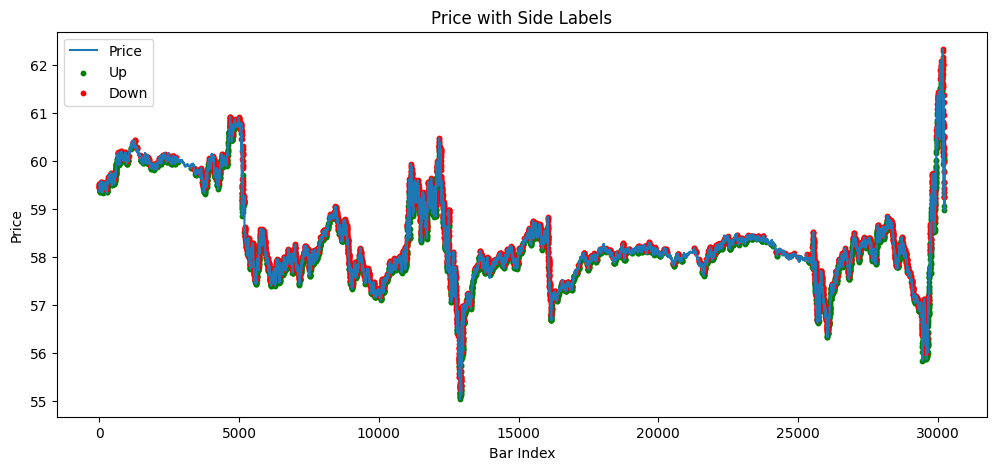

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['close'], label='Price')

# use index on x instead of time as some bars are dropped
plt.scatter(df.index[df['side'] == 1],
            df['close'][df['side'] == 1],
            color='green', s=10, label='Up')

plt.scatter(df.index[df['side'] == -1],
            df['close'][df['side'] == -1],
            color='red', s=10, label='Down')

plt.legend()
plt.title('Price with Side Labels')
plt.xlabel('Bar Index')
plt.ylabel('Price')
plt.show()

Price with side label overlay shows that the constructed labels generally track short-term price movements, suggesting the labeling scheme is capturing meaningful directional behavior in the data.

### Forward Return Distribution

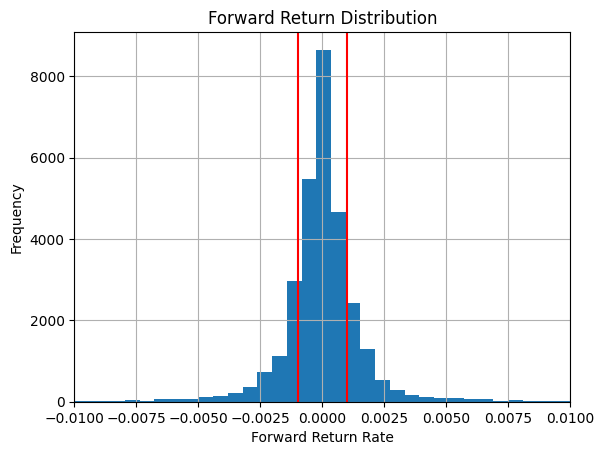

In [ ]:
df['future_return'].hist(bins=100)
plt.axvline(x=RETURN_THRESHOLD, color='red')
plt.axvline(x=-RETURN_THRESHOLD, color='red')
plt.title('Forward Return Distribution')
plt.xlabel('Forward Return Rate')
plt.ylabel('Frequency')
plt.xlim(-0.01,0.01)
plt.show()

Return distribution shows a large concentration of values near 0, indicating that most short-term price movements are small and dominated by noise, reinforcing the need for thresholding to filter out insignificant changes.

### Rolling Volatility Over Time

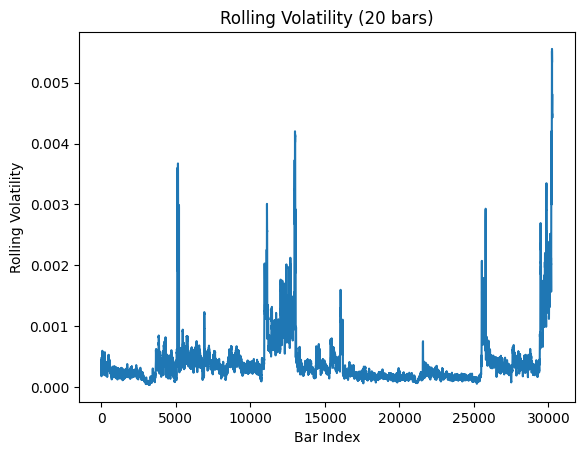

In [ ]:
plt.plot(df["rolling_std_20"])
plt.title("Rolling Volatility (20 bars)")
plt.xlabel("Bar Index")
plt.ylabel("Rolling Volatility")
plt.show()

There appears to be regime shifts near the middle and at the end. This
is marked by the increase in rolling volatility for a noticeable period
This further suggests that methods like side labeling using fixed
thresholds and return horizon may not work well, as the same parameters
can behave very differently across low- and high-volatility regimes,
leading to inconsistent and noisy labels